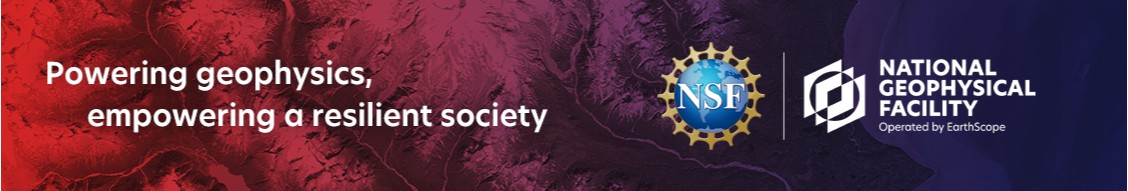

# Interactive Seismogram Widget

This notebook demonstrates the `interactive_seismogram_widget` module (imported here as `isw`), a Bokeh-based tool for looking at seismic waveforms and picking P/S arrivals directly in the notebook. This widget was originally built as a tool for Earthscope's [Seismology Skill Building Workshop](https://www.earthscope.org/education/skill-building-learning/courses/ssbw/).

The module exposes two entry points:

- **`isw.show(...)`** — an interactive picker for a *single* trace at a time, with a trace selector, multiple analysis views, filtering, and P/S picking.
- **`isw.show_components(...)`** — a read-only-ish, multi-trace view that stacks several waveforms (e.g. all components of a station) so they can be compared and picked together.

Both functions take a `pick_state` dictionary as their first argument, which is where picked arrival times are stored for later use in the same notebook.

## Setup the widget

Import the `interactive_seismogram_widget` module and call `isw.use_notebook()` once, which tells Bokeh to render plots inline in the notebook rather than opening a separate browser tab/server window. Output will confirm Bokeh has successfully loaded.

In [2]:
import interactive_seismogram_widget as isw
isw.use_notebook()

Loading BokehJS ...

## The Bokeh plot toolbar

Every plot in this widget has a vertical toolbar on the right with tools for navigating and interacting with the data:
<img src="./examples/bokeh_toolbar.webp" style="float: left; width: 60px; margin-right: 15px;">

- **Pan** (four-way arrow) — click and drag to move the visible plot area around.
  
- **Box Zoom** (dashed square with magnifier) — draw a rectangle to zoom into that region.

- **Zoom In** (magnifier with `+`) — click to zoom in around the cursor; scroll-wheel zoom also works once this tool is active.
- **Tap** (sparkle/wand) — click directly on the waveform to place a pick. This is what registers your **P** and **S** arrival picks.
- **Reset** (circular arrow) — restores the plot to its original zoom/pan state.
- **Save** (download arrow) — downloads the current view of the plot as a PNG image.
- **Fullscreen** (arrows pointing outward from a square) — expands the plot to fill the browser window. _Note: this will not work in stacked component view_
- **Hover** (speech bubble) — shows a tooltip with data values when you hover over the trace.
- **Crosshair** (circle with crosshair) — displays horizontal/vertical guide lines that follow your cursor, useful for reading off precise time/amplitude values.

_For more information about **Bokeh** see the [Documentation](https://docs.bokeh.org/en/latest/index.html)._

## Loading seismic data

The widget can be loaded using a stream from ObsPy, a miniSEED file, an SAC file, or a directory of SAC files. _For more information on using ObsPy to obtain seismic data, please see the [Documentation](https://docs.obspy.org/)._

We have a co-located sample directory of SAC files at `./examples/florida06/` from the September 10 MW5.9 Gulf Of Mexico earthquake and a miniSEED file at `./examples/mor00.miniseed` from the March 27, 2000 Mw5.3 Northern Mid-Atlantic Ridge earthquake.

For now, we will import `obspy` and preload a demo `Stream` using ObsPy's built-in example data (`obspy.read()`), which we'll pass to `show()` below. 

In [3]:
import obspy

stream = obspy.read() # loads the default stream from Obspy 

## `show()` — single-trace picker

`show(pick_state, data=None, trace_index=0, station=None, channel=None, component=None)` opens an interactive picker for **one trace at a time**. If the supplied stream has more than one trace, a **Trace** dropdown lets you switch between them.

The **View** selector at the top switches between four ways of looking at the currently displayed trace:

- **Waveform** — the raw (or filtered) time series. This is where P/S picking happens: click on the plot to place a pick at that time. The first click sets **P**, the second sets **S** (a status line tracks which phase is next), and the **Clear picks** button resets both.
- **Fourier amplitude (FFT)** — the amplitude spectrum of the displayed signal, useful for spotting dominant frequencies or instrument noise.
- **Power spectral density (PSD)** — a periodogram-based PSD estimate (in dB), showing how signal power is distributed across frequency.
- **Spectrogram** — a time-frequency view (dB-scaled), with adjustable **window length** and **overlap** controls that appear only in this mode. Handy for seeing how frequency content evolves over the course of the trace.

A **max freq** control caps the frequency axis shown for the FFT/PSD/spectrogram views. Below the view controls, a processing panel lets you apply a **filter** (bandpass/highpass/lowpass with adjustable corner frequencies and number of corners), a **taper**, and/or **smoothing**, then **Apply processing** (or **Reset raw** to undo). Whatever processing is active is reflected in whichever view you're looking at.

Finally, **Export picks** writes any picks made so far to a small tab-separated file under `picks/`.

Below we call `show()` on the `stream` we already loaded above.

In [4]:
# these must be defined ahead of time.
pick_state_1 = {
    "P": None,
    "S": None,
}

isw.show(pick_state_1, stream)

## `show_components()` — multi-trace comparison view

`show_components(pick_state, data=None, station=None, channel=None, component=None)` displays several traces at once, stacked vertically, so you can compare components (or any other filtered set of traces) side by side rather than switching between them one at a time. Unlike `show()`, there's no view-mode or single-trace selector — every trace is shown as a waveform. Up to 15 traces are shown per page, with **Previous/Next** controls to page through larger selections. The filtered data must contain at least two traces.

`data` can be a Stream/Trace, a file path, or (as below) a **directory of SAC files**, which is read automatically. The `station` and `channel` arguments accept ObsPy wildcard patterns, e.g. `channel="BH*"` to match all broadband high-gain channels for a station.

The example below loads every `BH*` channel for station `ANMO` from the `./florida06` SAC directory.

In [5]:
# these must be defined ahead of time
pick_state_2 = {
    "P": None,
    "S": None,
}

isw.show_components(pick_state_2, "./examples/florida06/", station="ANMO", channel="BH*")

## Getting your data back

Here, we can get `pick_state` back for use in python. Pick P and S above and then run the following cell.

In [ ]:
print(f"S arrived {pick_state_2["S"] - pick_state_2["P"]} seconds after P.")